Greyson Roy \
9\13\2026 \
Lab 3 - Oscillator Simulation

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Part A - The Simple Harmonic Oscillator

1. The function is written as specified below

In [4]:
k = 1.0
m = 1.0
Omega_0 = np.sqrt(k/m)
T = 2*np.pi/Omega_0

x_0 = 1.0
v_0 = 0.0
t_0 = 0.0

def x_exact_sol(t):
    return x_0 * np.cos(Omega_0 * t)

def v_exact_sol(t):
    return -x_0 * Omega_0 * np.sin(Omega_0 * t)

def simulate_sho(method, dt, n_periods = 10):
    """Simulates simple harmonic oscillator with 
    energy tracking, method is 'euler' or 'euler-cromer'
    """

    x = x_0
    v = v_0
    t = t_0
    E_total = 0.5*m*v**2 + 0.5*k*x**2

    state = {'t':[t], 'x':[x], 'v':[v], 'E':[E_total]}

    run_time = n_periods*T

    while t<=run_time:

        ax = - (k/m) * x

        if method == 'euler':
            x += v*dt
            v += ax*dt
        elif method == 'euler-cromer':
            v += ax*dt
            x += v*dt

        t += dt
        E_total = 0.5*m*v**2 + 0.5*k*x**2

        state['t'].append(t)
        state['x'].append(x)
        state['v'].append(v)
        state['E'].append(E_total)

    return state

2. Both runs of the function are called as specified below
3. The plot of x(t) vs time is below as specified
4. The plot of energy vs time is below as specified
5. From the energy - time plot, we can see that Euler's method is not accurate up to ten periods. The total of energy of the Euler's method simulation blows up, which is not realistic as we expect total energy to be conserved, i.e., stay constant. The Euler-Cromer simulation did not show this problem, as the associated total energy oscillated around the initial energy.

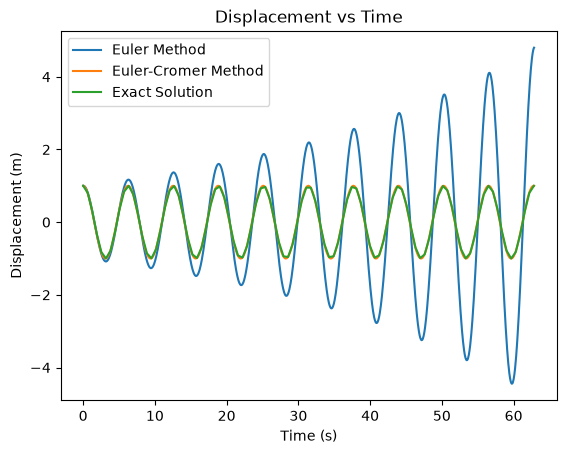

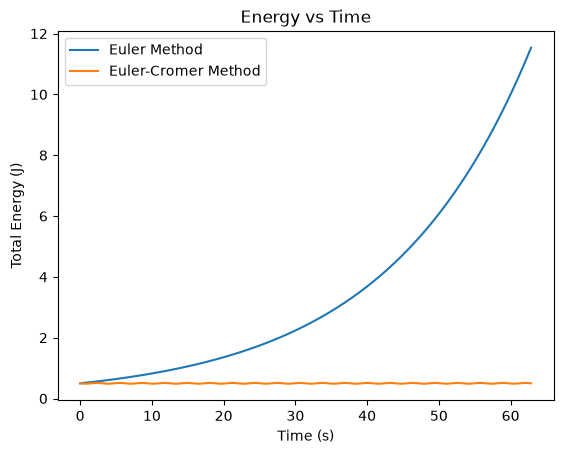

In [5]:
times = np.linspace(0,10*T,100)

exact_x = x_exact_sol(times)

euler_sim = simulate_sho('euler', 0.05)
cromer_sim = simulate_sho('euler-cromer', 0.05)

plt.plot(euler_sim['t'], euler_sim['x'], label = 'Euler Method')
plt.plot(cromer_sim['t'], cromer_sim['x'], label = 'Euler-Cromer Method')
plt.plot(times, exact_x, label = 'Exact Solution')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Displacement vs Time')
plt.legend()
plt.show()

plt.plot(euler_sim['t'], euler_sim['E'], label = 'Euler Method')
plt.plot(cromer_sim['t'], cromer_sim['E'], label = 'Euler-Cromer Method')
plt.xlabel('Time (s)')
plt.ylabel('Total Energy (J)')
plt.title('Energy vs Time')
plt.legend()
plt.show()

Part B - Phase Space and Damped Oscillations

B.1 Phase-Space Portraits

1. The phase space plot is below
2. The Euler curve spirals out, meaning the amplitude of the velocity and the displacement grow over time. This makes sense as we just saw that the total energy blows up and the associated quantities for kinetic and potential energy are velocity and displacement respectively. We would predict the Euler-Cromer curve would stay bounded around some radius, as the total energy is bounded around the initial energy. This is exactly what we see, with the curve following an elliptical path.

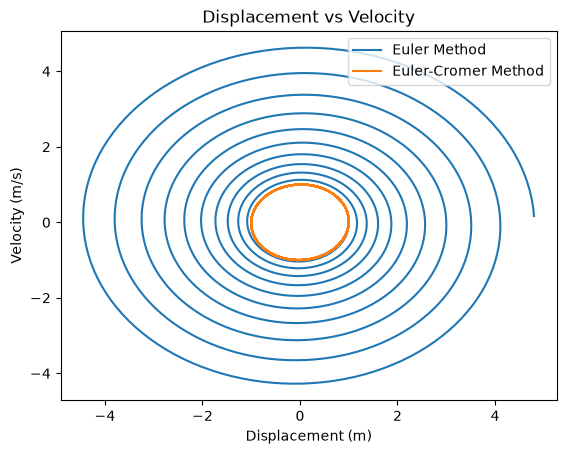

In [30]:
euler_sim = simulate_sho('euler', 0.05)
cromer_sim = simulate_sho('euler-cromer', 0.05)

plt.plot(euler_sim['x'], euler_sim['v'], label = 'Euler Method')
plt.plot(cromer_sim['x'], cromer_sim['v'], label = 'Euler-Cromer Method')
plt.xlabel('Displacement (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Displacement vs Velocity')
plt.legend()

B.2 - Add Damping

1. The simulator is extended below as specified

In [6]:
def x_exact_underdamp(t, b):
    beta = b/(2*m)
    Omega_1 = np.sqrt(Omega_0**2 - beta**2)
    return x_0 * np.e**(-beta*t)*np.cos(Omega_1*t)

def simulate_sho_damp(method, b, dt, n_periods = 10):

    x = x_0
    v = v_0
    t = t_0
    E_total = 0.5*m*v**2 + 0.5*k*x**2

    state = {'t':[t], 'x':[x], 'v':[v], 'E':[E_total]}

    run_time = n_periods*T

    while t<=run_time:

        ax = - (k/m) * x - (b/m) * v

        if method == 'euler':
            x += v*dt
            v += ax*dt
        elif method == 'euler-cromer':
            v += ax*dt
            x += v*dt

        t += dt
        E_total = 0.5*m*v**2 + 0.5*k*x**2

        state['t'].append(t)
        state['x'].append(x)
        state['v'].append(v)
        state['E'].append(E_total)

    return state

2. The three regimes are simulated below
3. Both plots are below as specified
4. From the phase space plot we can see that the underdampened curve spirals into the origin, continuing to oscillate with decreasing amplitude. We also see that both the critically and overdampened curves do not oscillate, as they fall directly to the origin rather than spiral, but while the critically dampened curve takes a nearly straight path to the origin, the overdampened curve takes a curved path to the origin, intitially gaining then gradually losing velocity.

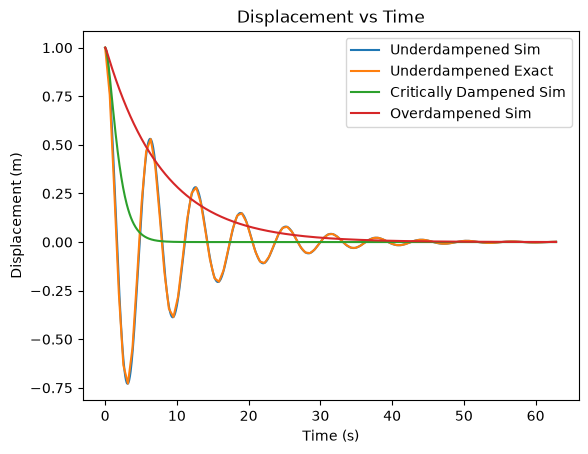

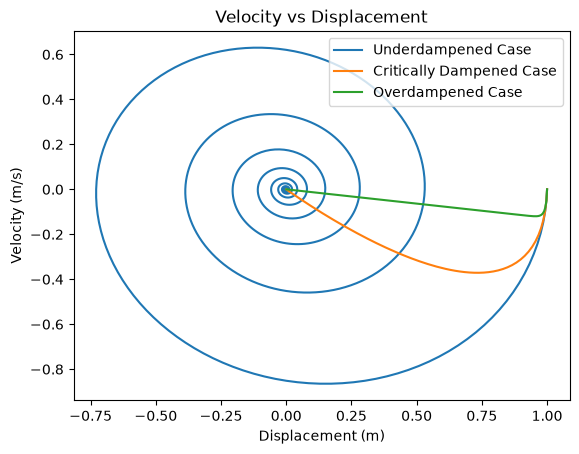

In [8]:
times = np.linspace(0,10*T,100)

underdamp_sim = simulate_sho_damp('euler-cromer', 0.2, 0.05)
critical_sim = simulate_sho_damp('euler-cromer', 2, 0.05)
overdamp_sim = simulate_sho_damp('euler-cromer', 8, 0.05)
underdamp_exact = x_exact_underdamp(times, 0.2)

plt.plot(underdamp_sim['t'], underdamp_sim['x'], label = 'Underdampened Sim')
plt.plot(times, underdamp_exact, label = 'Underdampened Exact')
plt.plot(critical_sim['t'], critical_sim['x'], label = 'Critically Dampened Sim')
plt.plot(overdamp_sim['t'], overdamp_sim['x'], label = 'Overdampened Sim')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Displacement vs Time')
plt.legend()
plt.show()

plt.plot(underdamp_sim['x'], underdamp_sim['v'], label = 'Underdampened Case')
plt.plot(critical_sim['x'], critical_sim['v'], label = 'Critically Dampened Case')
plt.plot(overdamp_sim['x'], overdamp_sim['v'], label = 'Overdampened Case')
plt.xlabel('Displacement (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Displacement')
plt.legend()

Part C - Driven Oscillations & Resonance

1. The driving term is added as specified

In [10]:
def simulate_sho_driven(method, b, F_0, w_d, dt, n_periods = 10):

    x = x_0
    v = v_0
    t = t_0
    E_total = 0.5*m*v**2 + 0.5*k*x**2

    state = {'t':[t], 'x':[x], 'v':[v], 'E':[E_total]}

    run_time = n_periods*T

    while t<=run_time:

        ax = - (k/m) * x - (b/m) * v + F_0 * np.cos(w_d*t)

        if method == 'euler':
            x += v*dt
            v += ax*dt
        elif method == 'euler-cromer':
            v += ax*dt
            x += v*dt

        t += dt
        E_total = 0.5*m*v**2 + 0.5*k*x**2

        state['t'].append(t)
        state['x'].append(x)
        state['v'].append(v)
        state['E'].append(E_total)

    return state

2. The driven simulation is run for many periods below as specified. Visually, we can see that the amplitude stabilizes at around 50-55 seconds. This is around where the transient state ends and steady state begins.

Text(0.5, 1.0, 'Displacement vs Time')

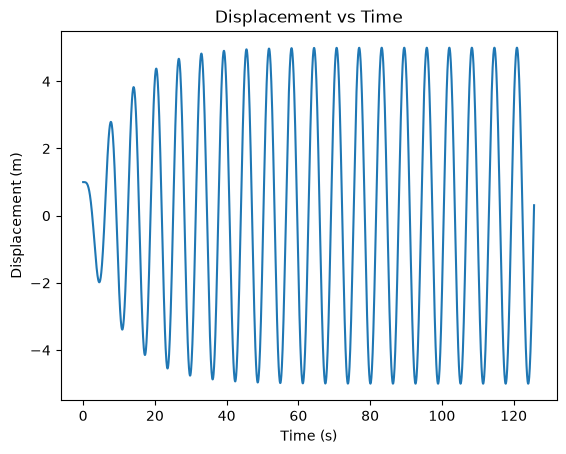

In [20]:
driven_sim = simulate_sho_driven('euler-cromer', 0.2, 1, 1, 0.05, n_periods=20)

plt.plot(driven_sim['t'], driven_sim['x'])
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Displacement vs Time')

3. The resonance curve is below as specified.
4. The amplitude appears to peak at a driving frequency of 1. This is where the driving frequency is equal to the natural frequency.
5. The amplitude peaks around the $\omega_{d} = \omega_{0}$ as at this point the driving force interacts constructively with the natural motion of the spring. With $\omega_{d} = \omega_{0}$, the driving force resonates with the spring and the dampening of the spring has the smallest effect. If you reduce the dampening of the spring, the peak of the resonance curve will increase and the width of the curve will decrease, resulting in a smaller curve. This is because the dampening has a disproportionate affect on the spring for driving frequencies further away from the natural frequency, as opposed to those near it.

Text(0.5, 1.0, 'Driving Freq. Vs Steady State Amp.')

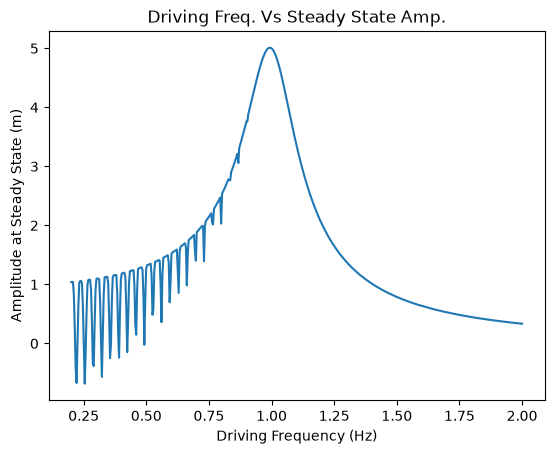

In [16]:
steady_amp = []
frequencies = []

for freq in np.linspace(0.2, 2, 500):
    dt = T/100
    frequencies.append(freq)
    steady_amp.append(max(simulate_sho_driven('euler-cromer', 0.2, 1, freq, dt, n_periods=30)['x'][2900:3000]))

plt.plot(frequencies, steady_amp)
plt.xlabel("Driving Frequency (Hz)")
plt.ylabel("Amplitude at Steady State (m)")
plt.title("Driving Freq. Vs Steady State Amp.")


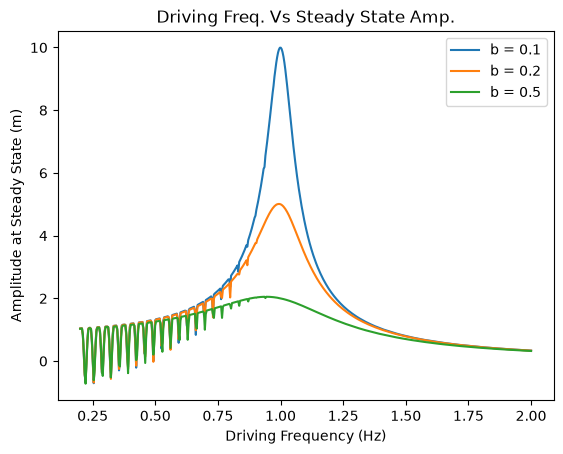

In [18]:
steady_amp = []
frequencies = []

for freq in np.linspace(0.2, 2, 500):
    dt = T/100
    frequencies.append(freq)
    steady_amp.append(max(simulate_sho_driven('euler-cromer', 0.1, 1, freq, dt, n_periods=30)['x'][2900:3000]))

plt.plot(frequencies, steady_amp, label='b = 0.1')

steady_amp = []
frequencies = []

for freq in np.linspace(0.2, 2, 500):
    dt = T/100
    frequencies.append(freq)
    steady_amp.append(max(simulate_sho_driven('euler-cromer', 0.2, 1, freq, dt, n_periods=30)['x'][2900:3000]))

plt.plot(frequencies, steady_amp, label='b = 0.2')

steady_amp = []
frequencies = []

for freq in np.linspace(0.2, 2, 500):
    dt = T/100
    frequencies.append(freq)
    steady_amp.append(max(simulate_sho_driven('euler-cromer', 0.5, 1, freq, dt, n_periods=30)['x'][2900:3000]))

plt.plot(frequencies, steady_amp, label='b = 0.5')

plt.xlabel("Driving Frequency (Hz)")
plt.ylabel("Amplitude at Steady State (m)")
plt.title("Driving Freq. Vs Steady State Amp.")
plt.legend()

Bonus - The Nonlinear Pendulum

1. The nonlinear pendulum function is below as specified

In [22]:
g = 9.81
m = 1.0
t_0 = 0.0

def simulate_pendulum(theta_0, L, dt, run_time):

    theta = np.deg2rad(theta_0)
    omega = 0.0
    t = t_0
    E_total = m*g*L*(1-np.cos(theta)) + 0.5*m*(omega**2)*(L**2)

    state = {'t':[t], 'theta':[theta], 'omega':[omega], 'E':[E_total]}

    while t<=run_time:

        a_theta = - (g/L) * np.sin(theta)

        omega += a_theta * dt
        theta += omega * dt

        t += dt
        E_total = m*g*L*(1-np.cos(theta)) + 0.5*m*(omega*L)**2

        state['t'].append(t)
        state['theta'].append(theta)
        state['omega'].append(omega)
        state['E'].append(E_total)

    return state

2. The period for a nonlinear pendulum of amplitude 5 deg was found below and matches the ideal period to within 1 percent

In [82]:
def period_approx(state):
    searching = True
    index_search = 1
    start = True
    period_sim = 0
    while searching == True:
        if start and state['theta'][index_search] > state['theta'][index_search - 1]:
            start = False
        if not start and state['theta'][index_search] < state['theta'][index_search - 1]:
            period_sim = state['t'][index_search-1]
            searching = False
        index_search += 1
    return period_sim

length_sim = 1
period = 2*np.pi*np.sqrt(length_sim/9.81)

five_deg_period = period_approx(simulate_pendulum(5, 1, 0.0001, 5))
print(f'With an amplitude of five degrees, the nonlinear pendulum has a period within {100-abs(100*period-five_deg_period)/period:.2f} percent of that of the ideal linear pendulum')

With an amplitude of five degrees, the nonlinear pendulum has a period within 1.00 percent of that of the ideal linear pendulum


3. The periods for angles 1 through 150 were found numerically and are plotted below
4. The period grows at an exponential rate with amplitude as seen in the loglog plot (if it were sub exponential it would be linear on the loglog plot). The small angle approximation has an error of 10 plus percent after ~60 degrees.

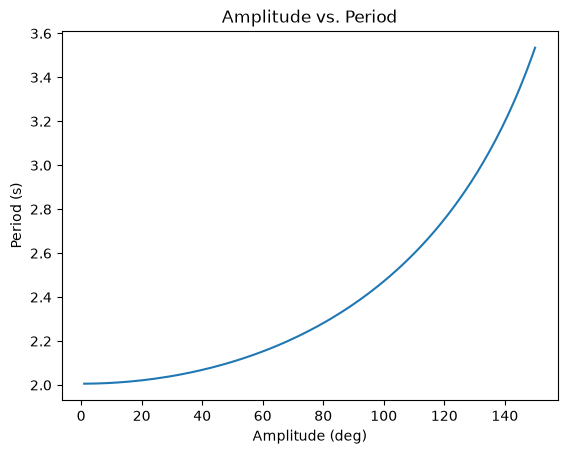

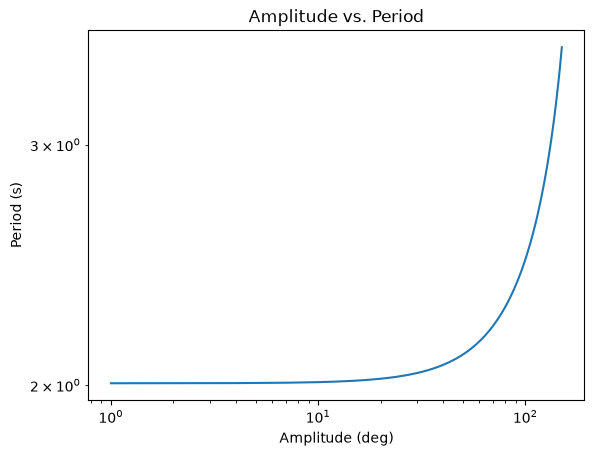

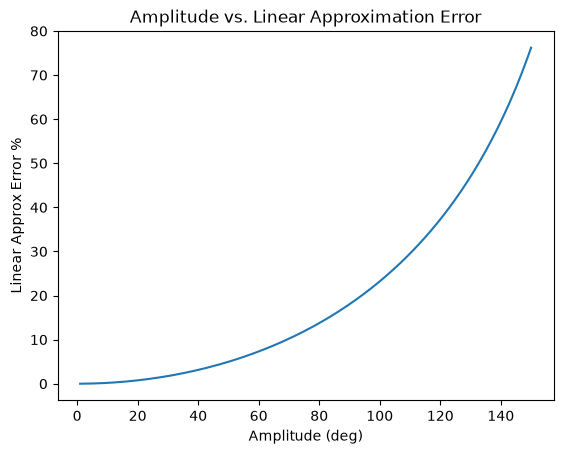

In [86]:
length_sim = 1

theta_sim = np.linspace(1,150,150)
period_sim = []

for amp in theta_sim:
    stat = simulate_pendulum(amp, length_sim, 0.0001, 5)
    period_sim.append(period_approx(stat))

plt.plot(theta_sim, period_sim)
plt.xlabel('Amplitude (deg)')
plt.ylabel('Period (s)')
plt.title('Amplitude vs. Period')
plt.show()
plt.loglog(theta_sim, period_sim)
plt.xlabel('Amplitude (deg)')
plt.ylabel('Period (s)')
plt.title('Amplitude vs. Period')
plt.show()
plt.plot(theta_sim, 100*abs(period_sim-period)/period)
plt.xlabel('Amplitude (deg)')
plt.ylabel('Linear Approx Error %')
plt.title('Amplitude vs. Linear Approximation Error')
plt.show()